# 02 — Campaign Scorecard

Overall commercial scoring for the fictional Salomon Ultra Glide 15 North America eCommerce campaign.

**Decision supported:** Did the active campaign deliver enough revenue, unit volume, and new-customer acquisition to meet plan?

## tl;dr

**Commercial score: Met target on all five illustrative KPIs.** During the March 2–April 12 active campaign, the business generated **$637.2K in net revenue**, sold **5,583 total units**, sold **1,435 Ultra Glide 15 units**, and acquired **1,499 new customers**. Among active-campaign Ultra Glide 15 customers, **44.2% were new**, comfortably above the documented 25% success criterion.

This is a topline commercial verdict—not the final campaign verdict. Later analysis should test incrementality, cannibalization, halo quality, inventory constraints, returns, and channel economics. Four numeric plan values below are explicit case assumptions because no official internal plan was provided.

## Context & Methods

- **Active period:** March 2–April 12, 2026.
- **Comparison:** Active-period daily averages versus pre-campaign daily averages; this avoids comparing unequal 42- and 56-day totals.
- **Revenue:** Net revenue after modeled discounts and recognized returns.
- **Quantity:** Units sold, including attached adjacent products.
- **New customers:** Unique customers whose active-period order is labeled `New`.
- **Ultra Glide 15 new-customer rate:** Unique active-period Ultra Glide 15 customers whose first Ultra Glide 15 order is labeled `New`.

### Key Assumptions

The repository defines a **25% Ultra Glide 15 new-customer-rate threshold**, but it does not provide numeric revenue, unit, franchise-volume, or acquired-customer plans. The parameter cell below therefore uses four editable, illustrative case targets. They must be replaced if an official plan becomes available.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
plt.style.use("seaborn-v0_8-whitegrid")

# Editable case targets. Only the 25% new-customer-rate threshold is documented
# in README.md; the other four are illustrative planning assumptions.
TARGETS = {
    "Active net revenue": 600_000,
    "Active total units": 5_200,
    "Ultra Glide 15 active units": 1_300,
    "Active new customers": 1_250,
    "Ultra Glide 15 new-customer rate": 0.25,
}

CAMPAIGN_START = pd.Timestamp("2026-03-02")
CAMPAIGN_END = pd.Timestamp("2026-04-12")

## Data

Sources are the reproducible mock CSVs in `data/mock/`. `ecommerce_daily.csv` controls topline revenue and units, `product_daily.csv` controls franchise sales, and `customer_orders.csv` controls customer acquisition.

In [2]:
ROOT = Path.cwd()
if not (ROOT / "data" / "mock").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data" / "mock"

ecommerce = pd.read_csv(DATA_DIR / "ecommerce_daily.csv", parse_dates=["date"])
products = pd.read_csv(DATA_DIR / "product_daily.csv", parse_dates=["date"])
orders = pd.read_csv(DATA_DIR / "customer_orders.csv", parse_dates=["order_date"])

source_inventory = pd.DataFrame(
    {
        "Source": ["ecommerce_daily.csv", "product_daily.csv", "customer_orders.csv"],
        "Rows": [len(ecommerce), len(products), len(orders)],
        "Start": [ecommerce.date.min(), products.date.min(), orders.order_date.min()],
        "End": [ecommerce.date.max(), products.date.max(), orders.order_date.max()],
        "Grain": ["Date", "Date × franchise", "Order"],
    }
)
display(source_inventory)

,Source,Rows,Start,End,Grain
0,ecommerce_daily.csv,126,2026-01-05,2026-05-10,Date
1,product_daily.csv,756,2026-01-05,2026-05-10,Date × franchise
2,customer_orders.csv,12589,2026-01-05,2026-05-10,Order


In [3]:
# Focused input checks before analysis.
assert ecommerce["date"].is_unique
assert not products.duplicated(["date", "franchise"]).any()
assert orders["order_id"].is_unique
assert ecommerce["date"].min() == pd.Timestamp("2026-01-05")
assert ecommerce["date"].max() == pd.Timestamp("2026-05-10")
assert ecommerce[["sessions", "orders", "units", "net_revenue"]].notna().all().all()
assert products[["franchise", "units_sold", "net_revenue"]].notna().all().all()
assert orders[["customer_id", "customer_type", "total_order_revenue"]].notna().all().all()
print("Input checks passed: expected grains, complete date range, unique keys, and no KPI nulls.")

Input checks passed: expected grains, complete date range, unique keys, and no KPI nulls.


## Results

In [4]:
active_ecommerce = ecommerce[ecommerce["campaign_phase"] == "Active campaign"].copy()
pre_ecommerce = ecommerce[ecommerce["campaign_phase"] == "Pre-campaign"].copy()
active_orders = orders[orders["campaign_phase"] == "Active campaign"].copy()
active_ultra = products[
    (products["campaign_phase"] == "Active campaign")
    & (products["franchise"] == "Ultra Glide 15")
].copy()

active_orders_sorted = active_orders.sort_values(["order_date", "order_id"])
ultra_orders = active_orders_sorted[
    active_orders_sorted["primary_product"] == "Ultra Glide 15"
]
ultra_customer_type = ultra_orders.groupby("customer_id")["customer_type"].first()

actuals = {
    "Active net revenue": active_ecommerce["net_revenue"].sum(),
    "Active total units": active_ecommerce["units"].sum(),
    "Ultra Glide 15 active units": active_ultra["units_sold"].sum(),
    "Active new customers": active_orders.loc[
        active_orders["customer_type"] == "New", "customer_id"
    ].nunique(),
    "Ultra Glide 15 new-customer rate": (ultra_customer_type == "New").mean(),
}

target_basis = {
    "Active net revenue": "Illustrative case plan",
    "Active total units": "Illustrative case plan",
    "Ultra Glide 15 active units": "Illustrative case plan",
    "Active new customers": "Illustrative case plan",
    "Ultra Glide 15 new-customer rate": "README success criterion",
}

scorecard = pd.DataFrame(
    [
        {
            "KPI": metric,
            "Actual": actual,
            "Target": TARGETS[metric],
            "Variance": actual - TARGETS[metric],
            "Attainment": actual / TARGETS[metric],
            "Status": "Met" if actual >= TARGETS[metric] else "Missed",
            "Target basis": target_basis[metric],
        }
        for metric, actual in actuals.items()
    ]
)

formatters = {
    "Active net revenue": lambda value: f"${value:,.0f}",
    "Active total units": lambda value: f"{value:,.0f}",
    "Ultra Glide 15 active units": lambda value: f"{value:,.0f}",
    "Active new customers": lambda value: f"{value:,.0f}",
    "Ultra Glide 15 new-customer rate": lambda value: f"{value:.1%}",
}

scorecard_display = scorecard.copy().astype({"Actual": "object", "Target": "object", "Variance": "object", "Attainment": "object"})
for row_index, row in scorecard_display.iterrows():
    formatter = formatters[row["KPI"]]
    scorecard_display.loc[row_index, "Actual"] = formatter(row["Actual"])
    scorecard_display.loc[row_index, "Target"] = formatter(row["Target"])
    if row["KPI"] == "Ultra Glide 15 new-customer rate":
        scorecard_display.loc[row_index, "Variance"] = f"{row['Variance'] * 100:+.1f} pp"
    else:
        scorecard_display.loc[row_index, "Variance"] = formatter(row["Variance"])
scorecard_display["Attainment"] = scorecard["Attainment"].map(lambda value: f"{value:.1%}")

overall_score = int((scorecard["Status"] == "Met").sum())
print(f"Overall commercial score: {overall_score}/{len(scorecard)} KPIs met")
display(scorecard_display)

Overall commercial score: 5/5 KPIs met


,KPI,Actual,Target,Variance,Attainment,Status,Target basis
0,Active net revenue,"$637,214","$600,000","$37,214",106.2%,Met,Illustrative case plan
1,Active total units,"5,583","5,200",383,107.4%,Met,Illustrative case plan
2,Ultra Glide 15 active units,"1,435","1,300",135,110.4%,Met,Illustrative case plan
3,Active new customers,"1,499","1,250",249,119.9%,Met,Illustrative case plan
4,Ultra Glide 15 new-customer rate,44.2%,25.0%,+19.2 pp,176.8%,Met,README success criterion


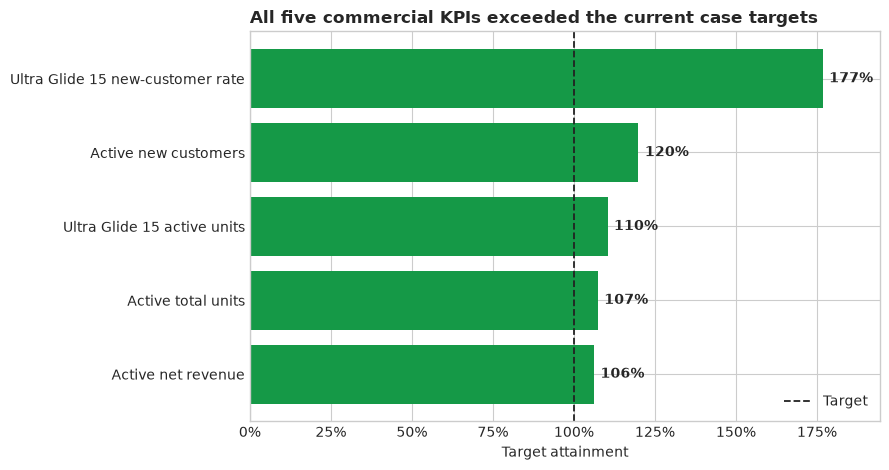

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
plot_data = scorecard.sort_values("Attainment")
colors = ["#159947" if status == "Met" else "#D84A3A" for status in plot_data["Status"]]
ax.barh(plot_data["KPI"], plot_data["Attainment"] * 100, color=colors)
ax.axvline(100, color="#222222", linestyle="--", linewidth=1.3, label="Target")
for index, value in enumerate(plot_data["Attainment"] * 100):
    ax.text(value + 2, index, f"{value:.0f}%", va="center", fontweight="bold")
ax.set_title("All five commercial KPIs exceeded the current case targets", loc="left", fontweight="bold")
ax.set_xlabel("Target attainment")
ax.set_xlim(0, max(190, plot_data["Attainment"].max() * 110))
ax.xaxis.set_major_formatter(lambda value, position: f"{value:.0f}%")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

In [6]:
def phase_metrics(frame):
    return pd.Series(
        {
            "Days": frame["date"].nunique(),
            "Sessions / day": frame["sessions"].sum() / frame["date"].nunique(),
            "Orders / day": frame["orders"].sum() / frame["date"].nunique(),
            "Units / day": frame["units"].sum() / frame["date"].nunique(),
            "Net revenue / day": frame["net_revenue"].sum() / frame["date"].nunique(),
            "Footwear revenue / day": frame["footwear_revenue"].sum() / frame["date"].nunique(),
            "Conversion rate": frame["orders"].sum() / frame["sessions"].sum(),
            "Average order value": frame["net_revenue"].sum() / frame["orders"].sum(),
        }
    )

period_comparison = pd.concat(
    {
        "Pre-campaign": phase_metrics(pre_ecommerce),
        "Active campaign": phase_metrics(active_ecommerce),
    },
    axis=1,
)
period_comparison["Active vs. pre"] = (
    period_comparison["Active campaign"] / period_comparison["Pre-campaign"] - 1
)

comparison_display = period_comparison.astype(object)
for metric in ["Sessions / day", "Orders / day", "Units / day"]:
    comparison_display.loc[metric, ["Pre-campaign", "Active campaign"]] = comparison_display.loc[
        metric, ["Pre-campaign", "Active campaign"]
    ].map(lambda value: f"{value:,.1f}")
for metric in ["Net revenue / day", "Footwear revenue / day", "Average order value"]:
    comparison_display.loc[metric, ["Pre-campaign", "Active campaign"]] = comparison_display.loc[
        metric, ["Pre-campaign", "Active campaign"]
    ].map(lambda value: f"${value:,.0f}")
comparison_display.loc["Conversion rate", ["Pre-campaign", "Active campaign"]] = comparison_display.loc[
    "Conversion rate", ["Pre-campaign", "Active campaign"]
].map(lambda value: f"{value:.2%}")
comparison_display.loc["Days", ["Pre-campaign", "Active campaign"]] = comparison_display.loc[
    "Days", ["Pre-campaign", "Active campaign"]
].map(lambda value: f"{value:.0f}")
comparison_display["Active vs. pre"] = period_comparison["Active vs. pre"].map(
    lambda value: "—" if not np.isfinite(value) else f"{value:+.1%}"
)
comparison_display.loc["Days", "Active vs. pre"] = "—"
display(comparison_display)

,Pre-campaign,Active campaign,Active vs. pre
Days,56,42,—
Sessions / day,"3,802.5","4,760.0",+25.2%
Orders / day,88.5,115.1,+30.0%
Units / day,100.9,132.9,+31.7%
Net revenue / day,"$10,908","$15,172",+39.1%
Footwear revenue / day,"$8,836","$12,926",+46.3%
Conversion rate,2.33%,2.42%,+3.9%
Average order value,$123,$132,+7.0%


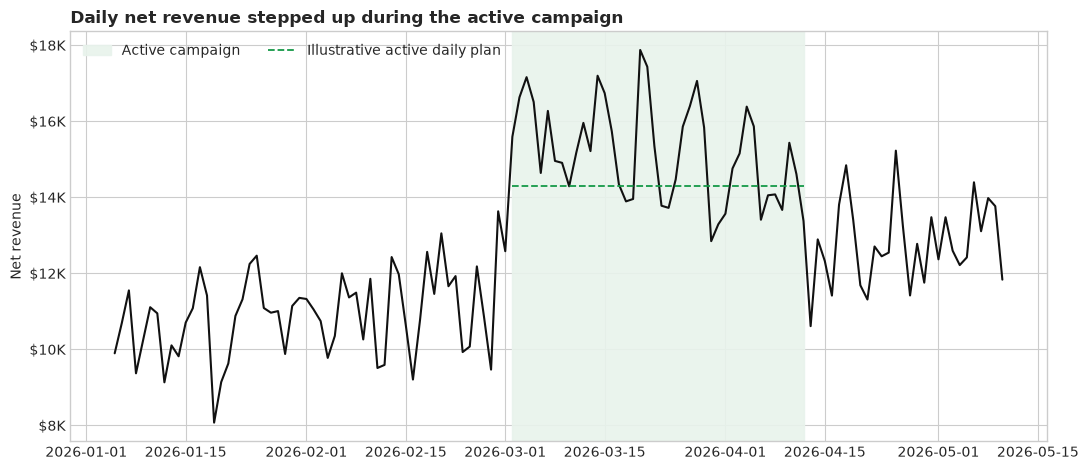

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.plot(ecommerce["date"], ecommerce["net_revenue"], color="#111111", linewidth=1.5)
ax.axvspan(CAMPAIGN_START, CAMPAIGN_END, color="#E8F3EC", alpha=0.9, label="Active campaign")
ax.hlines(
    y=TARGETS["Active net revenue"] / len(active_ecommerce),
    xmin=CAMPAIGN_START,
    xmax=CAMPAIGN_END,
    color="#159947",
    linestyle="--",
    linewidth=1.3,
    label="Illustrative active daily plan",
)
ax.set_title("Daily net revenue stepped up during the active campaign", loc="left", fontweight="bold")
ax.set_ylabel("Net revenue")
ax.yaxis.set_major_formatter(lambda value, position: f"${value / 1000:.0f}K")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

In [8]:
active_new_orders = active_orders[active_orders["customer_type"] == "New"]
customer_summary = pd.DataFrame(
    {
        "Metric": [
            "Active new customers",
            "New-customer share of active orders",
            "New-customer share of active net revenue",
            "Ultra Glide 15 active customers",
            "Ultra Glide 15 active new customers",
            "Ultra Glide 15 active new-customer rate",
        ],
        "Value": [
            active_new_orders["customer_id"].nunique(),
            len(active_new_orders) / len(active_orders),
            active_new_orders["total_order_revenue"].sum() / active_orders["total_order_revenue"].sum(),
            len(ultra_customer_type),
            int((ultra_customer_type == "New").sum()),
            (ultra_customer_type == "New").mean(),
        ],
    }
)

customer_summary_display = customer_summary.astype(object)
count_metrics = {
    "Active new customers",
    "Ultra Glide 15 active customers",
    "Ultra Glide 15 active new customers",
}
customer_summary_display["Value"] = customer_summary.apply(
    lambda row: f"{row['Value']:,.0f}" if row["Metric"] in count_metrics else f"{row['Value']:.1%}",
    axis=1,
)
display(customer_summary_display)

,Metric,Value
0,Active new customers,"1,499"
1,New-customer share of active orders,31.0%
2,New-customer share of active net revenue,30.5%
3,Ultra Glide 15 active customers,"1,335"
4,Ultra Glide 15 active new customers,590
5,Ultra Glide 15 active new-customer rate,44.2%


In [9]:
# Independent reconciliation of the headline actuals.
order_revenue = active_orders["total_order_revenue"].sum()
product_revenue = products[products["campaign_phase"] == "Active campaign"]["net_revenue"].sum()
assert np.isclose(actuals["Active net revenue"], order_revenue, atol=0.05)
assert np.isclose(actuals["Active net revenue"], product_revenue, atol=0.10)
assert actuals["Active total units"] == active_orders["units"].sum()
assert active_orders.loc[active_orders["customer_type"] == "New", "customer_id"].is_unique
print("Headline metrics reconcile across daily, product, and order-level sources.")

Headline metrics reconcile across daily, product, and order-level sources.


## Takeaways

1. **The campaign met the current commercial plan:** all five scorecard KPIs exceeded their targets, led by a 44.2% Ultra Glide 15 new-customer rate versus the documented 25% threshold.
2. **Growth combined volume and value:** active daily units increased 31.7% versus pre-campaign while average order value increased 7.0%, producing a 39.1% increase in daily net revenue.
3. **Ultra Glide 15 became a meaningful launch contributor:** the franchise generated 1,435 active-period units and $207.7K in active-period net revenue.
4. **Acquisition was material:** 1,499 new customers generated $194.2K, or 30.5% of active-period net revenue.
5. **The verdict is conditional:** four targets are illustrative case assumptions, and topline success does not yet prove incremental profit. Cannibalization, halo, inventory, returns, and channel efficiency require separate analysis before the executive conclusion is final.